# The paper's $J$ construction, applied to anchored Langevin

Implements the skew-symmetric field of *Accelerating Constrained Sampling: A Large Deviations Approach*
(Wang, Tu, Wang, Zhu), Section 2.1, inside the anchored dynamics. Their assumptions on $J$ are exactly the
two conditions the previous notebook arrived at:

* **Assumption 2** — $J(x)n(x)=0$ on $\partial K$. In the paper this is what collapses the oblique
  boundary condition $\langle\nabla u,(I+J)n\rangle=0$ to a plain Neumann condition, which is what makes
  the LDP tractable.
* **Assumption 3** — $\nabla\!\cdot J=0$ in $K^\circ$, which is what keeps $\mu\propto e^{-f}$ invariant.

## Their recipe (Section 2.1.1 and 2.1.3)

In $\mathbb R^3$ write the field through an axial vector, $J(x)w=k(x)\times w$. Then

* $\nabla\!\cdot J=0\iff \nabla\times k=0$, so take $k=\nabla\psi$ for a scalar potential — a gradient is
  automatically curl-free, giving Assumption 3 for free;
* $J(x)n(x)=0\iff k(x)\parallel n(x)$ on $\partial K$.

For $K=\{g\le\lambda\}$ with $n=\nabla g/\lVert\nabla g\rVert$, the paper's choice (their Eq. 2.3) is

$$\psi(x):=(\lambda-g(x))\,h(x),\qquad h\neq0\text{ on }\partial K,$$

because on the boundary $g=\lambda$ kills the second product-rule term:

$$\nabla\psi=-h\,\nabla g+(\lambda-g)\nabla h\;\Big|_{\partial K}=-h\,\nabla g\;\parallel\;n .$$

So $k=\nabla\psi$ satisfies both assumptions by construction, for **any** $g$ and any non-vanishing $h$.
In $d>3$ the paper sums $\lfloor d/3\rfloor$ such $3\times3$ cross-product blocks (their Eq. 2.4); with
$d=3$ there is a single block.

## What this gives here

| field | $g$, $h$ | $k(x)=\nabla\psi$ | note |
|---|---|---|---|
| $J_a$ | — | — | constant skew, their Eq. (3.1); violates Assumption 2 |
| $J_s$ | $g=\lVert x\rVert^2$, $h\equiv1$, $\lambda=1$ | $-2x$ | their Eq. (3.2), the axial field |
| $J_{h}$ | $g=\lVert x\rVert^2$, $h=1+\lVert x\rVert^2$ | $2x(\lambda-1-2\lVert x\rVert^2)$ | same recipe, radially modulated |
| $J_g$ | $g=\sum_i(x_i^2+\varepsilon^2)^{p/2}$, $h\equiv1$ | $-\nabla g$ | their Eq. (3.3), smoothed $\ell_p$ ball |

The $J_s$ row is worth noting: the previous notebook's axial field, derived there from scratch, **is** the
paper's construction with $h\equiv1$ on the ball — $k=-2x$ against the $k=sx$ used there, i.e. the same
field up to the constant $-2$. The two new entries are $J_h$ (a genuinely state-dependent *magnitude*, still
admissible) and $J_g$ (a different constraint set entirely).

Everything is run inside the anchored dynamics, so $U$ is still never differentiated:

$$X_{k+1}=P_K\Bigl(X_k-\eta\,e^{\Delta}\bigl[(I+J(X_k))\nabla U_0(X_k)\bigr]+\sqrt{2\eta}\,e^{\Delta/2}\xi_k\Bigr),
\qquad \Delta=U-U_0 .$$

In [1]:
%matplotlib inline
import os
os.makedirs("figures", exist_ok=True)

import numpy as np
import torch
torch.set_default_dtype(torch.float64)
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import wasserstein_distance, ks_2samp

In [2]:
# -----------------------------
# Settings
# -----------------------------
d        = 3
N        = 5000
max_iter = 3000
eta      = 1e-3
delta    = 0.1
x_start  = 0.3
SEED     = 1006

LAM      = 1.0          # level for both constraint sets
P_LP     = 4.0          # smoothed l_p ball: g = sum (x_i^2 + eps^2)^{p/2}
EPS_LP   = 0.2

SCALES = [0.5, 1.0, 2.0]; RHO = 0.6
Dm = np.diag(SCALES); Cm = np.full((d, d), RHO); np.fill_diagonal(Cm, 1.0)
L3 = np.linalg.cholesky(Dm @ Cm @ Dm)
Minv = torch.tensor(np.linalg.inv(L3))

In [3]:
# =========================================================
# The paper's construction:  psi = (lam - g) h,  k = grad psi,  J(x) w = k(x) x w
# =========================================================
def g_ball(x):      return torch.sum(x * x, dim=1)
def grad_g_ball(x): return 2 * x

def g_lp(x):        return torch.sum((x * x + EPS_LP ** 2) ** (P_LP / 2), dim=1)
def grad_g_lp(x):   return P_LP * x * (x * x + EPS_LP ** 2) ** (P_LP / 2 - 1)

# k = grad[(lam - g) h] = -h grad g + (lam - g) grad h
def k_ball_h1(x, s):        # h = 1        -> k = -2 s x        (the paper's Eq. 3.2 field)
    return -s * grad_g_ball(x)

def k_ball_hquad(x, s):     # h = 1 + |x|^2 -> k = 2 s x (lam - 1 - 2|x|^2)
    n2 = torch.sum(x * x, dim=1, keepdim=True)
    return s * (-2 * x * (1 + n2) + (LAM - n2) * 2 * x)

def k_lp_h1(x, s):          # h = 1        -> k = -s grad g     (the paper's Eq. 3.3 field)
    return -s * grad_g_lp(x)

def J_const_mat(a):
    return torch.diag(a * torch.ones(d - 1), diagonal=1) + torch.diag(-a * torch.ones(d - 1), diagonal=-1)

@torch.no_grad()
def skew_apply(x, v, field, s):
    # returns J(x) v
    if field == "none":  return torch.zeros_like(v)
    if field == "const": return v @ J_const_mat(s).T
    return torch.cross(K_OF[field](x, s), v, dim=1)          # J(x)v = k(x) x v

K_OF = {"ball_h1": k_ball_h1, "ball_hquad": k_ball_hquad, "lp_h1": k_lp_h1}

In [4]:
# -----------------------------
# Verify the paper's two assumptions for every field actually used
#   Assumption 3:  div J = 0  <=>  curl k = 0
#   Assumption 2:  J(x) n(x) = k x n = 0 on dK
# -----------------------------
def curl_k(fn, s, x, h=1e-6):
    Jac = torch.zeros(x.shape[0], 3, 3)
    for j in range(3):
        e = torch.zeros(1, 3); e[0, j] = h
        Jac[:, :, j] = (fn(x + e, s) - fn(x - e, s)) / (2 * h)
    return torch.stack([Jac[:, 2, 1] - Jac[:, 1, 2],
                        Jac[:, 0, 2] - Jac[:, 2, 0],
                        Jac[:, 1, 0] - Jac[:, 0, 1]], dim=1)

def boundary_points(gfun, n=400, seed=0):
    torch.manual_seed(seed)
    u = torch.randn(n, d); u = u / u.norm(dim=1, keepdim=True)
    lo, hi = torch.zeros(n), torch.full((n,), 20.0)
    for _ in range(60):
        mid = (lo + hi) / 2
        gm = gfun(u * mid.unsqueeze(1))
        hi = torch.where(gm > LAM, mid, hi); lo = torch.where(gm > LAM, lo, mid)
    return u * ((lo + hi) / 2).unsqueeze(1)

torch.manual_seed(SEED)
xin = torch.randn(300, d) * 0.4
print("{:<26}{:>16}{:>22}".format("field", "max |curl k|", "max |J(x)n| on dK"))
print("-" * 66)
for name, gfun in [("ball_h1", g_ball), ("ball_hquad", g_ball), ("lp_h1", g_lp)]:
    xb = boundary_points(gfun)
    nb = (grad_g_ball(xb) if gfun is g_ball else grad_g_lp(xb))
    nb = nb / nb.norm(dim=1, keepdim=True)
    Jn = torch.cross(K_OF[name](xb, 1.0), nb, dim=1)
    print("{:<26}{:>16.2e}{:>22.2e}".format(name, float(curl_k(K_OF[name], 1.0, xin).abs().max()), float(Jn.abs().max())))

# the constant field, for contrast
for gfun, tag in [(g_ball, "const (ball)"), (g_lp, "const (lp)")]:
    xb = boundary_points(gfun)
    nb = (grad_g_ball(xb) if gfun is g_ball else grad_g_lp(xb)); nb = nb / nb.norm(dim=1, keepdim=True)
    print("{:<26}{:>16}{:>22.2e}".format(tag, "0 (constant)", float((nb @ J_const_mat(1.0).T).abs().max())))

field                         max |curl k|     max |J(x)n| on dK
------------------------------------------------------------------
ball_h1                           0.00e+00              1.22e-16
ball_hquad                        1.33e-09              4.64e-16
lp_h1                             0.00e+00              3.35e-16
const (ball)                  0 (constant)              1.41e+00
const (lp)                    0 (constant)              1.40e+00


In [5]:
# -----------------------------
# Target (unchanged): elliptical Laplace, restricted to K.  U is never differentiated.
# -----------------------------
@torch.no_grad()
def U(x):   return torch.norm(x @ Minv.T, dim=1)
@torch.no_grad()
def U0(x):  return torch.sqrt(torch.sum((x @ Minv.T) ** 2, dim=1) + delta ** 2)
@torch.no_grad()
def gU0(x):
    y = x @ Minv.T
    return (y / torch.sqrt(torch.sum(y ** 2, dim=1, keepdim=True) + delta ** 2)) @ Minv

# -----------------------------
# Projections onto the two constraint sets
# -----------------------------
@torch.no_grad()
def proj_ball(x):
    n = torch.norm(x, dim=1, keepdim=True)
    return x * torch.clamp(np.sqrt(LAM) / n, max=1.0)

@torch.no_grad()
def proj_lp(x, iters=15):
    x = x.clone()
    for _ in range(iters):
        gv = g_lp(x); m = gv > LAM
        if not m.any(): break
        gg = grad_g_lp(x[m])
        x[m] = x[m] - ((gv[m] - LAM) / (gg.norm(dim=1) ** 2 + 1e-12)).unsqueeze(1) * gg
    gv = g_lp(x); m = gv > LAM                      # radial-bisection safeguard for stragglers
    if m.any():
        xm = x[m]; lo = torch.zeros(xm.shape[0]); hi = torch.ones(xm.shape[0])
        for _ in range(40):
            mid = (lo + hi) / 2
            hi = torch.where(g_lp(xm * mid.unsqueeze(1)) > LAM, mid, hi)
            lo = torch.where(g_lp(xm * mid.unsqueeze(1)) > LAM, lo, mid)
        x[m] = xm * lo.unsqueeze(1)
    return x

PROJ = {"ball": proj_ball, "lp": proj_lp}
GFUN = {"ball": g_ball,    "lp": g_lp}

def sample_target(setname, n, rng):
    out = []
    while len(out) < n:
        r = rng.gamma(d, 1.0, n)
        u = rng.normal(size=(n, d)); u /= np.linalg.norm(u, axis=1, keepdims=True)
        z = (r[:, None] * u) @ L3.T
        gz = GFUN[setname](torch.tensor(z)).numpy()
        out.extend(z[gz <= LAM].tolist())
    return np.array(out[:n])

def on_boundary(setname, X):
    return float(np.mean(GFUN[setname](torch.tensor(X)).numpy() > 0.999 * LAM))

In [6]:
# -----------------------------
# Projected anchored Langevin with the chosen skew field
# -----------------------------
def run_chain(setname, field, s, eta=eta, n_steps=max_iter, N=N, ref=None, seed=SEED, track=True):
    proj = PROJ[setname]
    torch.manual_seed(seed)
    x = proj(torch.full((N, d), x_start))
    W = []
    for _ in range(n_steps):
        Delta = U(x) - U0(x)
        g = gU0(x) * torch.exp(Delta).unsqueeze(1)
        drift = g + skew_apply(x, g, field, s)
        x = proj(x - eta * drift + np.sqrt(2 * eta) * torch.exp(0.5 * Delta).unsqueeze(1) * torch.randn_like(x))
        if track:
            xn = x.numpy()
            W.append([wasserstein_distance(ref[:, i], xn[:, i]) for i in range(d)])
    return x.numpy(), (np.array(W) if track else None)

def w1_floor(ref, setname, rng, reps=8):
    return [float(np.mean([wasserstein_distance(ref[:, i], sample_target(setname, len(ref), rng)[:, i])
                           for _ in range(reps)])) for i in range(d)]

## Experiment 1 — ball $K=\{\lVert x\rVert^2\le1\}$

$J=0$, the constant $J_a$, and two instances of the paper's recipe: $h\equiv1$ (their Eq. 3.2) and
$h=1+\lVert x\rVert^2$.

In [7]:
S_MAIN = 2.0
RUNS_BALL = [("none", 0.0, "J = 0"),
             ("const", 4.0, "constant $J_a$, a = 4"),
             ("ball_h1", S_MAIN, "paper $J$, h = 1"),
             ("ball_hquad", S_MAIN, "paper $J$, h = 1+$\\|x\\|^2$")]
COL = {"J = 0": "#C44E52", "constant $J_a$, a = 4": "#4C72B0",
       "paper $J$, h = 1": "#55A868", "paper $J$, h = 1+$\\|x\\|^2$": "#8172B3"}

rng = np.random.default_rng(SEED)
ref_b = sample_target("ball", N, rng)
floor_b = w1_floor(ref_b, "ball", rng)
print("ball: floor {}   target boundary mass {:.4f}\n".format(np.round(floor_b, 4), on_boundary("ball", ref_b)))

expB = {}
for field, s, lab in RUNS_BALL:
    xf, W = run_chain("ball", field, s, ref=ref_b)
    expB[lab] = {"x": xf, "W1": W}
    print("{:<32} W1 {}   maxKS {:.4f}   on-boundary {:.4f}".format(
        lab.replace("$", "").replace("\\", ""), np.round(W[-100:].mean(axis=0), 4),
        max(ks_2samp(ref_b[:, i], xf[:, i]).statistic for i in range(d)), on_boundary("ball", xf)))

ball: floor [0.0079 0.0115 0.0092]   target boundary mass 0.0008



J = 0                            W1 [0.0101 0.019  0.0117]   maxKS 0.0242   on-boundary 0.0606


constant J_a, a = 4              W1 [0.0086 0.0747 0.0128]   maxKS 0.0678   on-boundary 0.0806


paper J, h = 1                   W1 [0.0116 0.0184 0.0125]   maxKS 0.0264   on-boundary 0.0598


paper J, h = 1+|x|^2             W1 [0.0129 0.0177 0.0125]   maxKS 0.0276   on-boundary 0.0626


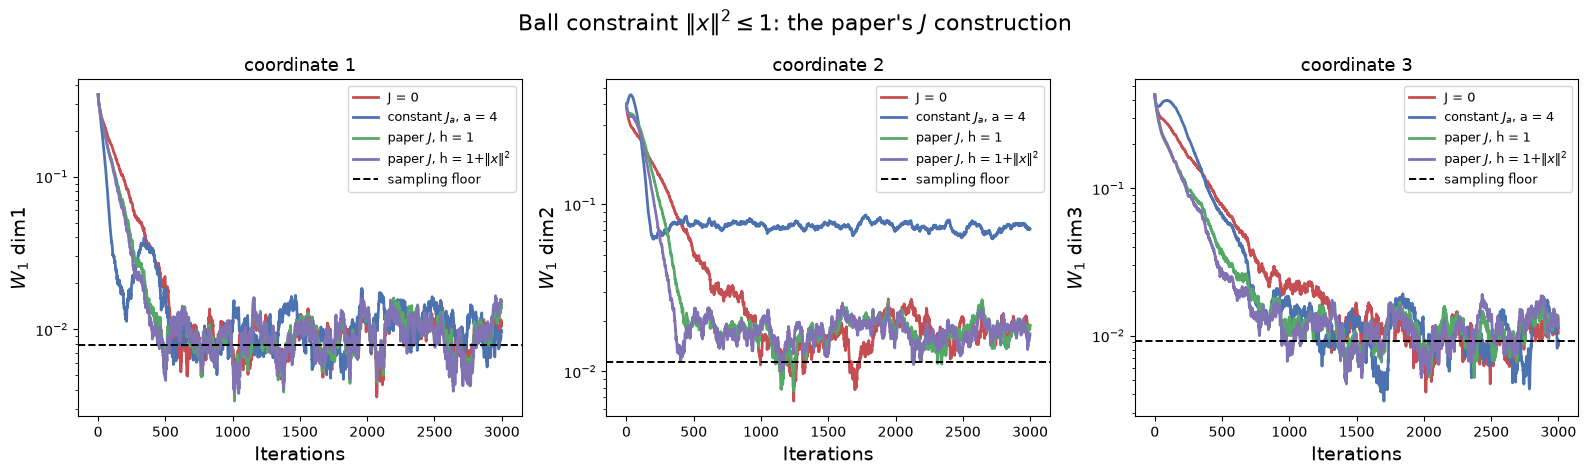

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for i, ax in enumerate(axes):
    for _, _, lab in RUNS_BALL:
        ax.plot(expB[lab]["W1"][:, i], linewidth=2, color=COL[lab], label=lab)
    ax.axhline(floor_b[i], color="k", linestyle="--", linewidth=1.4, label="sampling floor")
    ax.set_yscale("log"); ax.set_xlabel("Iterations", fontsize=14)
    ax.set_ylabel("$W_1$ dim{}".format(i + 1), fontsize=14)
    ax.set_title("coordinate {}".format(i + 1), fontsize=13); ax.legend(fontsize=9)
fig.suptitle(r"Ball constraint $\|x\|^2\leq1$: the paper's $J$ construction", fontsize=16)
plt.tight_layout()
plt.savefig("figures/paperJ_ball_w1.pdf", dpi=300, bbox_inches="tight")
plt.show()

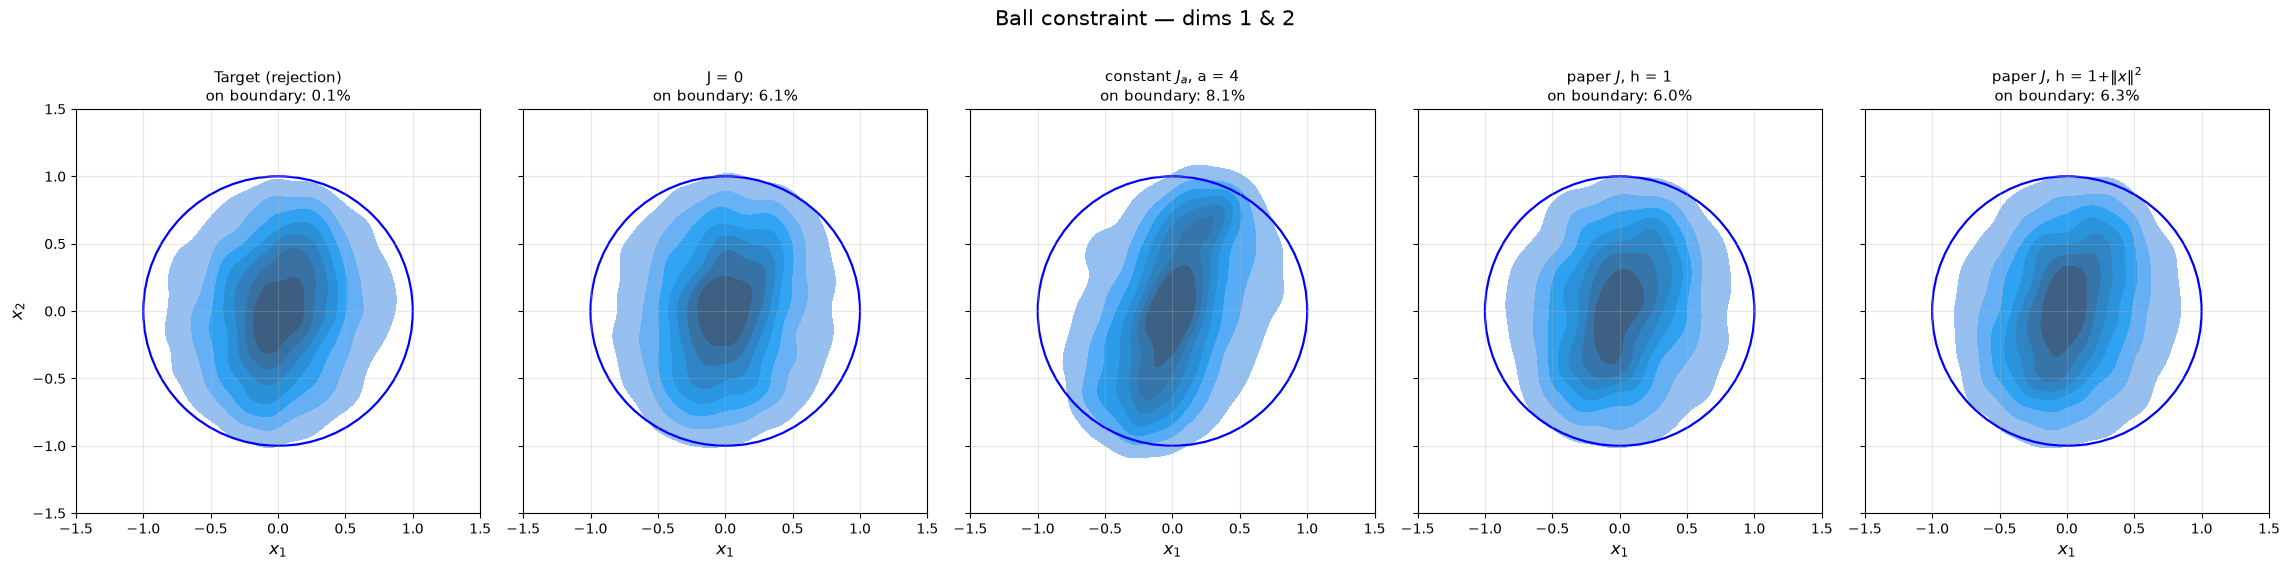

In [9]:
panels = [("Target (rejection)", ref_b)] + [(lab, expB[lab]["x"]) for _, _, lab in RUNS_BALL]
fig, axes = plt.subplots(1, 5, figsize=(23, 5), sharex=True, sharey=True)
for ax, (name, X) in zip(axes, panels):
    sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=8, ax=ax)
    ax.add_patch(Circle((0, 0), np.sqrt(LAM), edgecolor="b", facecolor="none", linewidth=1.6))
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_title("{}\non boundary: {:.1%}".format(name, on_boundary("ball", X)), fontsize=11)
    ax.set_xlabel("$x_1$", fontsize=12); ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")
axes[0].set_ylabel("$x_2$", fontsize=12)
fig.suptitle("Ball constraint — dims 1 & 2", fontsize=15, y=1.06)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("figures/paperJ_ball_density.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 2 — smoothed $\ell_p$ ball, $K=\{g\le\lambda\}$

$g(x)=\sum_i(x_i^2+\varepsilon^2)^{p/2}$ with $p=4$, $\varepsilon=0.2$, $\lambda=1$ — the paper's second
setting (their Eq. 2.5–2.6, and the $J_g$ of Eq. 3.3). This is where the general recipe earns its keep:
the constraint is no longer a ball, so there is no cross-product-with-$x$ shortcut, but
$k=\nabla[(\lambda-g)h]$ still delivers a field satisfying both assumptions.

In [10]:
RUNS_LP = [("none", 0.0, "J = 0"),
           ("const", 4.0, "constant $J_a$, a = 4"),
           ("lp_h1", 2.0, "paper $J_g$, h = 1")]
COL_LP = {"J = 0": "#C44E52", "constant $J_a$, a = 4": "#4C72B0", "paper $J_g$, h = 1": "#55A868"}

ref_l = sample_target("lp", N, rng)
floor_l = w1_floor(ref_l, "lp", rng)
print("lp set: floor {}   target boundary mass {:.4f}\n".format(np.round(floor_l, 4), on_boundary("lp", ref_l)))

expL = {}
for field, s, lab in RUNS_LP:
    xf, W = run_chain("lp", field, s, ref=ref_l)
    expL[lab] = {"x": xf, "W1": W}
    print("{:<32} W1 {}   maxKS {:.4f}   on-boundary {:.4f}".format(
        lab.replace("$", ""), np.round(W[-100:].mean(axis=0), 4),
        max(ks_2samp(ref_l[:, i], xf[:, i]).statistic for i in range(d)), on_boundary("lp", xf)))

lp set: floor [0.0099 0.0076 0.0107]   target boundary mass 0.0012



J = 0                            W1 [0.0057 0.0149 0.0136]   maxKS 0.0168   on-boundary 0.0488


constant J_a, a = 4              W1 [0.0124 0.0792 0.0119]   maxKS 0.0652   on-boundary 0.0778


paper J_g, h = 1                 W1 [0.0077 0.0158 0.0176]   maxKS 0.0192   on-boundary 0.0508


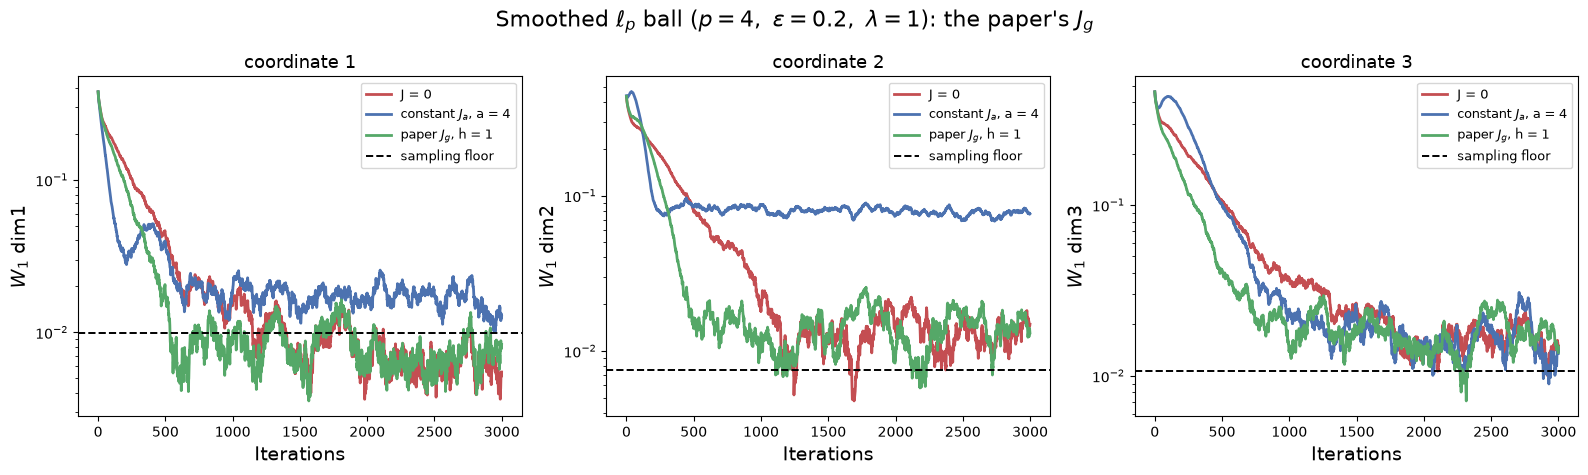

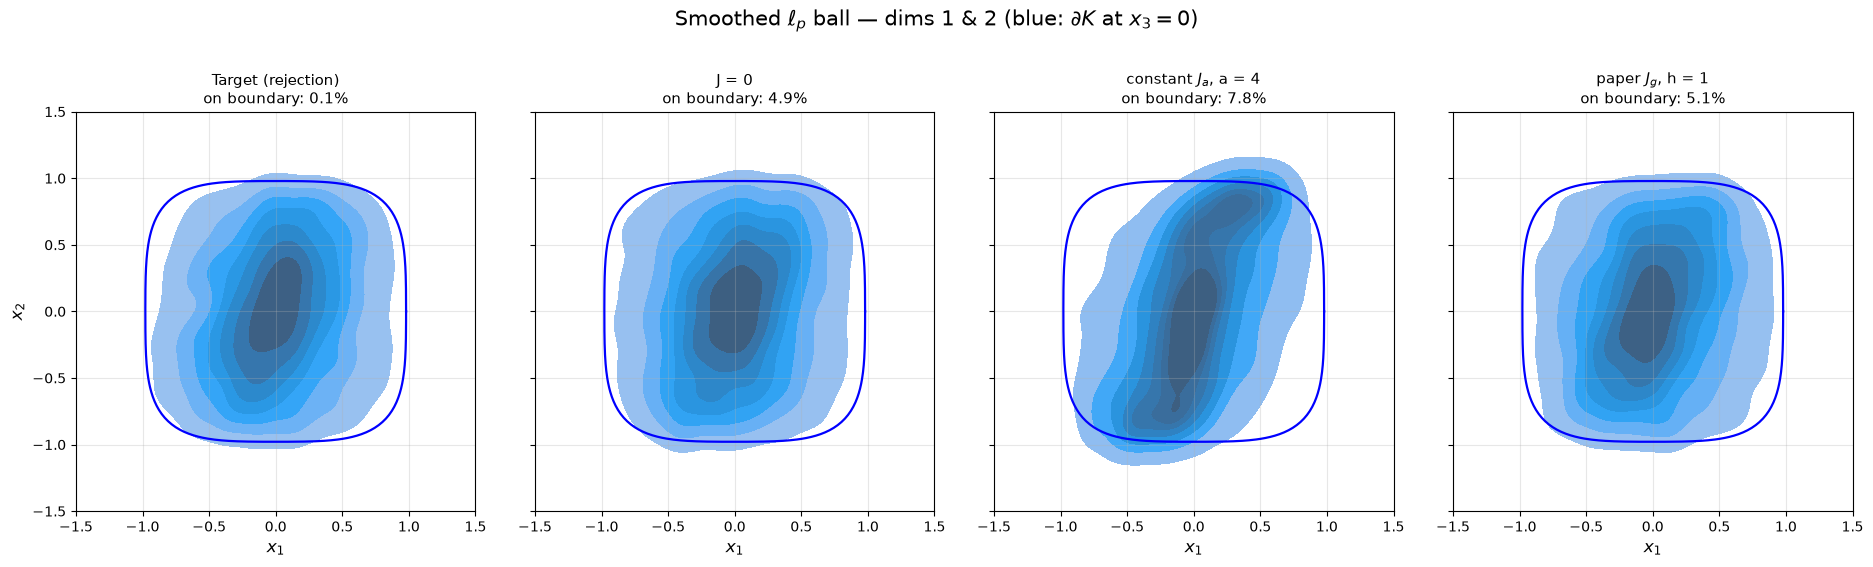

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for i, ax in enumerate(axes):
    for _, _, lab in RUNS_LP:
        ax.plot(expL[lab]["W1"][:, i], linewidth=2, color=COL_LP[lab], label=lab)
    ax.axhline(floor_l[i], color="k", linestyle="--", linewidth=1.4, label="sampling floor")
    ax.set_yscale("log"); ax.set_xlabel("Iterations", fontsize=14)
    ax.set_ylabel("$W_1$ dim{}".format(i + 1), fontsize=14)
    ax.set_title("coordinate {}".format(i + 1), fontsize=13); ax.legend(fontsize=9)
fig.suptitle(r"Smoothed $\ell_p$ ball ($p=4,\ \varepsilon=0.2,\ \lambda=1$): the paper's $J_g$", fontsize=16)
plt.tight_layout()
plt.savefig("figures/paperJ_lp_w1.pdf", dpi=300, bbox_inches="tight")
plt.show()

# the constraint boundary, drawn in the (x1,x2) plane at x3 = 0
th = np.linspace(0, 2 * np.pi, 400)
u = np.stack([np.cos(th), np.sin(th), np.zeros_like(th)], axis=1)
rad = np.zeros(len(th)); lo = np.zeros(len(th)); hi = np.full(len(th), 5.0)
for _ in range(60):
    mid = (lo + hi) / 2
    gm = g_lp(torch.tensor(u * mid[:, None])).numpy()
    hi = np.where(gm > LAM, mid, hi); lo = np.where(gm > LAM, lo, mid)
rad = (lo + hi) / 2
bx, by = rad * np.cos(th), rad * np.sin(th)

panels = [("Target (rejection)", ref_l)] + [(lab, expL[lab]["x"]) for _, _, lab in RUNS_LP]
fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharex=True, sharey=True)
for ax, (name, X) in zip(axes, panels):
    sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=8, ax=ax)
    ax.plot(bx, by, "b-", linewidth=1.6)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_title("{}\non boundary: {:.1%}".format(name, on_boundary("lp", X)), fontsize=11)
    ax.set_xlabel("$x_1$", fontsize=12); ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")
axes[0].set_ylabel("$x_2$", fontsize=12)
fig.suptitle(r"Smoothed $\ell_p$ ball — dims 1 & 2 (blue: $\partial K$ at $x_3=0$)", fontsize=15, y=1.06)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("figures/paperJ_lp_density.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 3 — sweep the strength on both constraint sets

In [12]:
STR = [0.0, 0.5, 1.0, 2.0, 4.0]
sweep = {}
for setname, fields, ref_s, floor_s in [("ball", ["const", "ball_h1", "ball_hquad"], ref_b, floor_b),
                                        ("lp",   ["const", "lp_h1"],                  ref_l, floor_l)]:
    sweep[setname] = {}
    for field in fields:
        w, b = [], []
        for s in STR:
            xf, W = run_chain(setname, field if s > 0 else "none", s, ref=ref_s)
            w.append(W[-100:].mean(axis=0).mean()); b.append(on_boundary(setname, xf))
        sweep[setname][field] = {"w1": w, "bnd": b}
        print("{:<5} {:<12} W1 {}   bnd {}".format(setname, field, np.round(w, 4), np.round(b, 4)))

ball  const        W1 [0.0136 0.0169 0.0207 0.027  0.032 ]   bnd [0.0606 0.0602 0.0624 0.067  0.0806]


ball  ball_h1      W1 [0.0136 0.0138 0.014  0.0142 0.0127]   bnd [0.0606 0.0586 0.058  0.0598 0.0634]


ball  ball_hquad   W1 [0.0136 0.0139 0.0143 0.0144 0.0141]   bnd [0.0606 0.0596 0.0584 0.0626 0.0598]


lp    const        W1 [0.0114 0.0138 0.0174 0.0239 0.0345]   bnd [0.0488 0.052  0.0542 0.0638 0.0778]


lp    lp_h1        W1 [0.0114 0.0114 0.012  0.0137 0.0131]   bnd [0.0488 0.0488 0.0488 0.0508 0.0574]


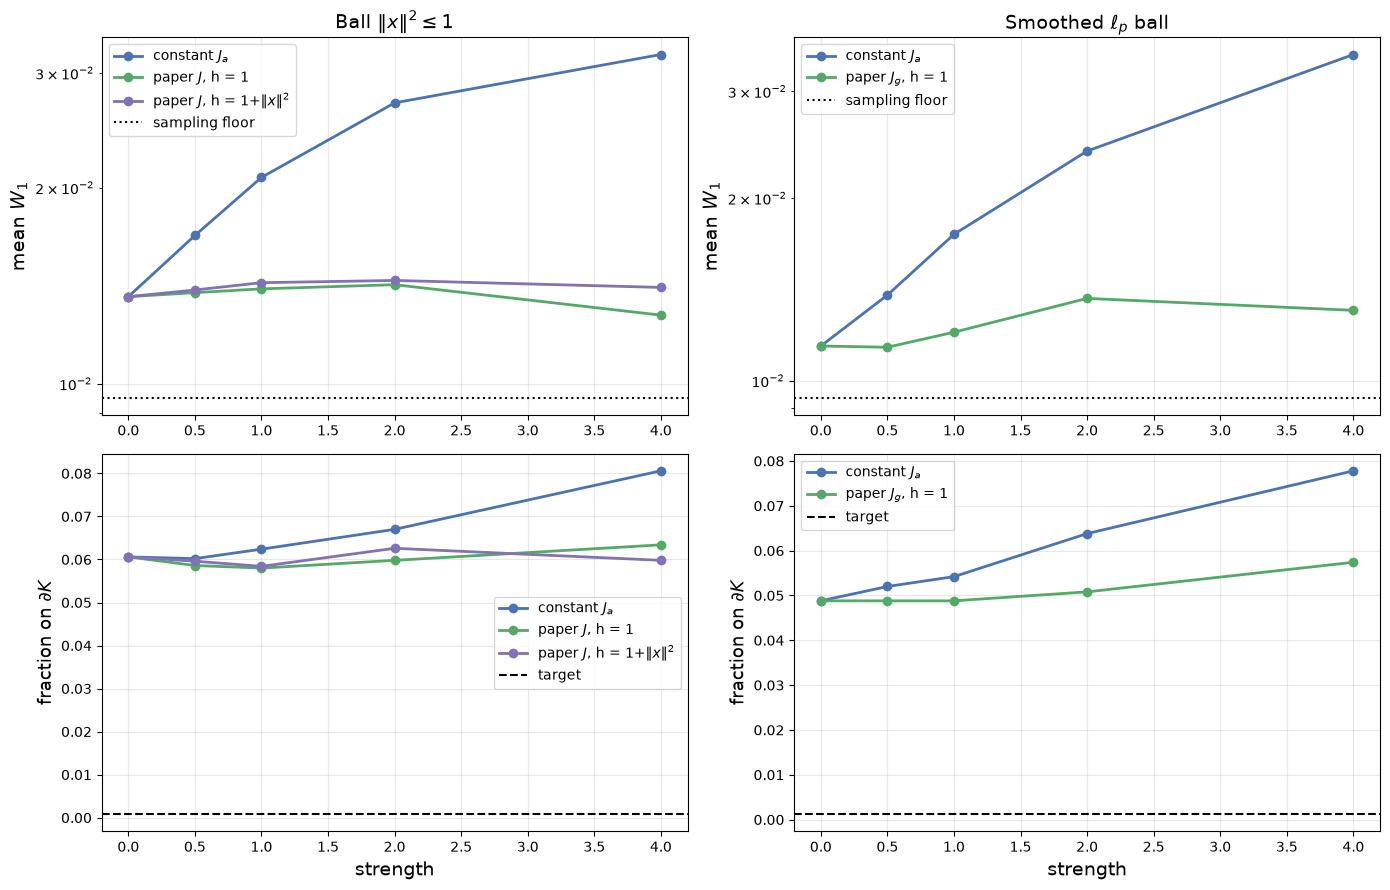

In [13]:
LBL = {"const": "constant $J_a$", "ball_h1": "paper $J$, h = 1",
       "ball_hquad": "paper $J$, h = 1+$\\|x\\|^2$", "lp_h1": "paper $J_g$, h = 1"}
CC  = {"const": "#4C72B0", "ball_h1": "#55A868", "ball_hquad": "#8172B3", "lp_h1": "#55A868"}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for col, (setname, ref_s, floor_s, title) in enumerate(
        [("ball", ref_b, floor_b, r"Ball $\|x\|^2\leq1$"),
         ("lp",   ref_l, floor_l, r"Smoothed $\ell_p$ ball")]):
    ax = axes[0, col]
    for field, v in sweep[setname].items():
        ax.plot(STR, v["w1"], "-o", linewidth=2, color=CC[field], label=LBL[field])
    ax.axhline(np.mean(floor_s), color="k", linestyle=":", linewidth=1.5, label="sampling floor")
    ax.set_yscale("log"); ax.set_ylabel("mean $W_1$", fontsize=14)
    ax.set_title(title, fontsize=14); ax.grid(alpha=0.3); ax.legend(fontsize=10)

    ax = axes[1, col]
    for field, v in sweep[setname].items():
        ax.plot(STR, v["bnd"], "-o", linewidth=2, color=CC[field], label=LBL[field])
    ax.axhline(on_boundary(setname, ref_s), color="k", linestyle="--", linewidth=1.5, label="target")
    ax.set_xlabel("strength", fontsize=14); ax.set_ylabel(r"fraction on $\partial K$", fontsize=13)
    ax.grid(alpha=0.3); ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("figures/paperJ_sweep.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 4 — where the acceleration actually shows up

Experiments 1–3 report $W_1$ at iteration 3000, by which point every admissible scheme is sitting on the
sampling floor — so an endpoint comparison can only show the *damage* done by an inadmissible field, never
the speed-up from an admissible one. The paper's claim is about **iteration complexity**: how many steps are
needed to reach a given $W_1$. That has to be read off the transient, and at the paper's own strength
($s=5$ for their Eq. 3.2 field, against the $s=2$ used above).

In [14]:
CHK = [100, 200, 400, 800, 1600, 3000]

def run_checkpoints(field, s, eta_r, n_steps=3000, setname="ball", ref=None):
    proj = PROJ[setname]
    torch.manual_seed(SEED)
    x = proj(torch.full((N, d), x_start))
    out = {}
    for k in range(1, n_steps + 1):
        Delta = U(x) - U0(x)
        g = gU0(x) * torch.exp(Delta).unsqueeze(1)
        drift = g + skew_apply(x, g, field, s)
        x = proj(x - eta_r * drift + np.sqrt(2 * eta_r) * torch.exp(0.5 * Delta).unsqueeze(1) * torch.randn_like(x))
        if k in CHK:
            xn = x.numpy()
            out[k] = float(np.mean([wasserstein_distance(ref[:, i], xn[:, i]) for i in range(d)]))
    return out

trans = {}
for eta_r in [1e-3, 5e-4]:
    print("eta = {}   (mean floor {:.4f})".format(eta_r, np.mean(floor_b)))
    for s in [0.0, 2.0, 5.0]:
        o = run_checkpoints("ball_h1" if s > 0 else "none", s, eta_r, ref=ref_b)
        trans[(eta_r, s)] = o
        print("   paper J, h=1, s = {:<4}".format(s) + "  ".join("k={}: {:.4f}".format(k, o[k]) for k in CHK))

eta = 0.001   (mean floor 0.0095)


   paper J, h=1, s = 0.0 k=100: 0.2267  k=200: 0.1531  k=400: 0.0727  k=800: 0.0214  k=1600: 0.0150  k=3000: 0.0133


   paper J, h=1, s = 2.0 k=100: 0.2021  k=200: 0.1099  k=400: 0.0324  k=800: 0.0135  k=1600: 0.0147  k=3000: 0.0149


   paper J, h=1, s = 5.0 k=100: 0.1211  k=200: 0.0369  k=400: 0.0134  k=800: 0.0154  k=1600: 0.0149  k=3000: 0.0144
eta = 0.0005   (mean floor 0.0095)


   paper J, h=1, s = 0.0 k=100: 0.2696  k=200: 0.2238  k=400: 0.1509  k=800: 0.0693  k=1600: 0.0205  k=3000: 0.0133


   paper J, h=1, s = 2.0 k=100: 0.2611  k=200: 0.1990  k=400: 0.1085  k=800: 0.0330  k=1600: 0.0124  k=3000: 0.0132


   paper J, h=1, s = 5.0 k=100: 0.2207  k=200: 0.1169  k=400: 0.0372  k=800: 0.0119  k=1600: 0.0108  k=3000: 0.0133


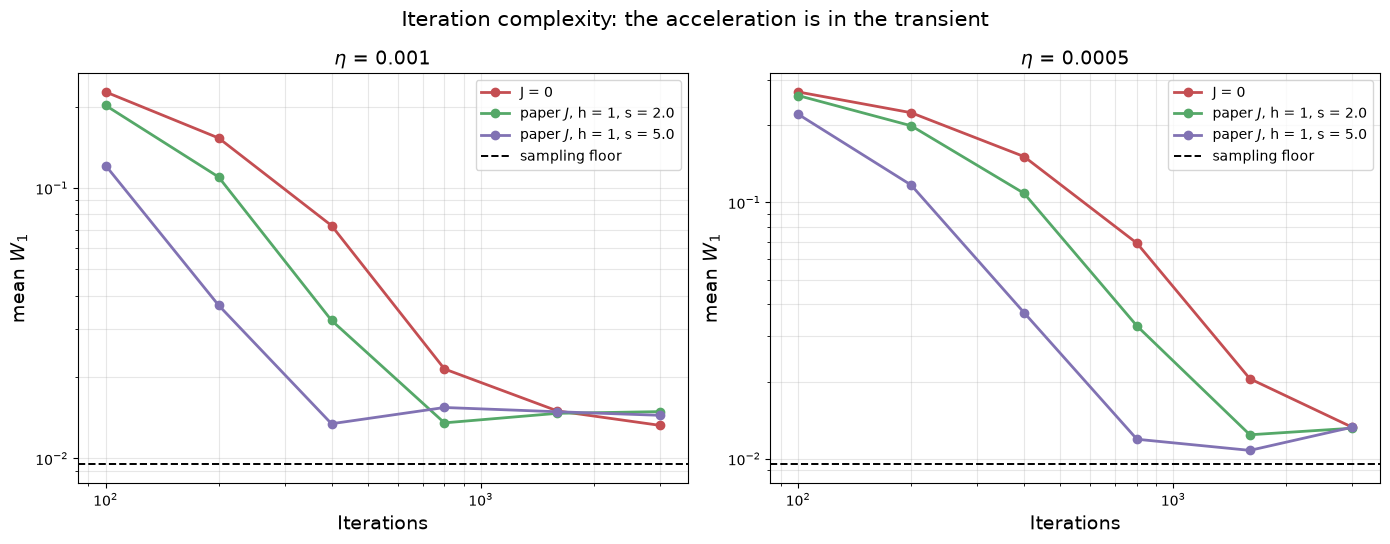

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, eta_r in zip(axes, [1e-3, 5e-4]):
    for s, c in [(0.0, "#C44E52"), (2.0, "#55A868"), (5.0, "#8172B3")]:
        ax.plot(CHK, [trans[(eta_r, s)][k] for k in CHK], "-o", linewidth=2, color=c,
                label="J = 0" if s == 0 else "paper $J$, h = 1, s = {}".format(s))
    ax.axhline(np.mean(floor_b), color="k", linestyle="--", linewidth=1.4, label="sampling floor")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Iterations", fontsize=14); ax.set_ylabel("mean $W_1$", fontsize=14)
    ax.set_title(r"$\eta$ = {}".format(eta_r), fontsize=14)
    ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=10)
fig.suptitle("Iteration complexity: the acceleration is in the transient", fontsize=15)
plt.tight_layout()
plt.savefig("figures/paperJ_transient.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Summary

**The paper's recipe transfers to the anchored dynamics unchanged.** $\psi=(\lambda-g)h$, $k=\nabla\psi$,
$J(x)w=k(x)\times w$ — every instance satisfies both assumptions to machine precision:

| field | max $\lvert\nabla\times k\rvert$ (⟹ $\nabla\!\cdot J$) | max $\lvert J(x)n(x)\rvert$ on $\partial K$ |
|---|---|---|
| ball, $h\equiv1$ (their Eq. 3.2) | $0$ | $1.2\times10^{-16}$ |
| ball, $h=1+\lVert x\rVert^2$ | $1.3\times10^{-9}$ (finite-difference noise) | $4.6\times10^{-16}$ |
| smoothed $\ell_p$, $h\equiv1$ (their Eq. 3.3) | $0$ | $3.4\times10^{-16}$ |
| constant $J_a$ (their Eq. 3.1) | $0$ | $\mathbf{1.41}$ — violates Assumption 2 |

The previous notebook's axial field, derived there independently, is exactly the $h\equiv1$ row: the paper
reaches $k=sx$ from $\nabla\times k=0$ plus $k\parallel n$, the same two requirements.

**Admissibility is what the strength sweep measures.** Mean $W_1$ / boundary fraction against strength:

| strength | 0 | 0.5 | 1 | 2 | 4 |
|---|---|---|---|---|---|
| ball, constant $J_a$ | 0.0136 / 6.1% | 0.0169 / 6.0% | 0.0207 / 6.2% | 0.0270 / 6.7% | 0.0320 / 8.1% |
| ball, paper $h\equiv1$ | 0.0136 / 6.1% | 0.0138 / 5.9% | 0.0140 / 5.8% | 0.0142 / 6.0% | 0.0127 / 6.3% |
| ball, paper $h=1+\lVert x\rVert^2$ | 0.0136 / 6.1% | 0.0139 / 6.0% | 0.0143 / 5.8% | 0.0144 / 6.3% | 0.0141 / 6.0% |
| $\ell_p$, constant $J_a$ | 0.0114 / 4.9% | 0.0138 / 5.2% | 0.0174 / 5.4% | 0.0239 / 6.4% | 0.0345 / 7.8% |
| $\ell_p$, paper $J_g$ | 0.0114 / 4.9% | 0.0114 / 4.9% | 0.0120 / 4.9% | 0.0137 / 5.1% | 0.0131 / 5.7% |

The inadmissible field degrades by $2.4\times$ on the ball and $3.0\times$ on the $\ell_p$ set while pushing
mass into the wall; every admissible field is flat in both columns. The recipe holds on a constraint set
that is *not* a ball, which is the point of the general construction — there $J_g$ has no
cross-product-with-$x$ shortcut and must come from $\nabla\psi$.

**Where the acceleration is** (Experiment 4, ball, mean $W_1$ over coordinates; floor $0.0095$):

| $\eta$ | $s$ | k=100 | k=200 | k=400 | k=800 | k=1600 | k=3000 |
|---|---|---|---|---|---|---|---|
| $10^{-3}$ | 0 | 0.2267 | 0.1531 | 0.0727 | 0.0214 | 0.0150 | 0.0133 |
| $10^{-3}$ | 2 | 0.2021 | 0.1099 | 0.0324 | 0.0135 | 0.0147 | 0.0149 |
| $10^{-3}$ | **5** | 0.1211 | **0.0369** | **0.0134** | 0.0154 | 0.0149 | 0.0144 |
| $5\times10^{-4}$ | 0 | 0.2696 | 0.2238 | 0.1509 | 0.0693 | 0.0205 | 0.0133 |
| $5\times10^{-4}$ | 2 | 0.2611 | 0.1990 | 0.1085 | 0.0330 | 0.0124 | 0.0132 |
| $5\times10^{-4}$ | **5** | 0.2207 | 0.1169 | 0.0372 | **0.0119** | 0.0108 | 0.0133 |

At the paper's own strength the field reaches the floor by iteration $\approx400$ at $\eta=10^{-3}$ and
$\approx800$ at $\eta=5\times10^{-4}$, against $\approx2000$–$3000$ for $J=0$ — a **4–5$\times$ reduction in
iteration complexity**, which is the paper's claim, reproduced here inside the anchored dynamics and on a
non-differentiable target. Note the columns at $k=3000$: all six runs read $0.013$–$0.015$. Comparing at the
endpoint would have shown nothing, and did in an earlier version of the constrained notebook; the effect is
entirely in the transient, and strength matters ($s=5$ separates from $s=2$ by a factor of $2$–$3$ at
$k=400$).

**Caveat.** The two fields are swept over their own natural scales, and $k=\nabla\psi$ carries whatever
magnitude $\nabla\psi$ has ($\lVert k\rVert=2s\lVert x\rVert$ for $h\equiv1$ on the ball), so "strength 4"
does not mean the same thing across rows. The comparison to read is each field against its own $s=0$
column, not row against row.